In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [105]:
df = pd.read_csv('/content/Student_Performance.csv')
display(df.head(10))

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


# number of rows number of columns data types summary

In [106]:
# Get number of rows and columns
print(f"Shape of the dataset: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Get data types
print("\nData Types:")
display(df.dtypes)

# Get summary statistics
print("\nSummary Statistics:")
display(df.describe(include='all'))

Shape of the dataset: (10000, 6)
Number of rows: 10000
Number of columns: 6

Data Types:


,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64



Summary Statistics:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


#Check missing values

In [107]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [108]:
print("Column names in the dataset:")
print(df.columns.tolist())

Column names in the dataset:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


# duplicate row number

In [109]:
# Identify duplicate rows
duplicate_rows = df[df.duplicated()]

print(f"Number of duplicate rows: {len(duplicate_rows)}")
if len(duplicate_rows) > 0:
    print("\nDuplicate Rows:")
    display(duplicate_rows)

Number of duplicate rows: 127

Duplicate Rows:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


#show the percentage of duplicate row

In [110]:
# Calculate the percentage of duplicate rows
total_rows = len(df)
duplicate_count = df.duplicated().sum()
percentage_duplicates = (duplicate_count / total_rows) * 100

print(f"Total rows: {total_rows}")
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {percentage_duplicates:.2f}%")

Total rows: 10000
Number of duplicate rows: 127
Percentage of duplicate rows: 1.27%


#remove the duplicate rows

In [111]:
# Remove duplicate rows and reset the index
df = df.drop_duplicates().reset_index(drop=True)

print(f"New dataset shape: {df.shape}")
print(f"Number of duplicates remaining: {df.duplicated().sum()}")
display(df.head())

New dataset shape: (9873, 6)
Number of duplicates remaining: 0


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


#binary encoding in Extracurricular Activities

In [112]:
# Re-read the column and apply mapping correctly
import pandas as pd
original_data = pd.read_csv('/content/Student_Performance.csv')
# Align with current index after drop_duplicates
df['Extracurricular Activities'] = original_data.iloc[df.index]['Extracurricular Activities'].values

# Map 'Yes' to 1 and 'No' to 0
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

print("Unique values in 'Extracurricular Activities':", df['Extracurricular Activities'].unique())
display(df.head())

Unique values in 'Extracurricular Activities': [1 0]


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


#Define Features and Target Variable

In [113]:
# Define Features (X) and Target (y)
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

print("Features (X) columns:", X.columns.tolist())
print("Target (y) name: Performance Index")

# Display first few rows of Features and Target
print("\nFirst 5 rows of Features (X):")
display(X.head())
print("\nFirst 5 rows of Target (y):")
display(y.head())

Features (X) columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
Target (y) name: Performance Index

First 5 rows of Features (X):


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5



First 5 rows of Target (y):


,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


#Correlation Analysis

Correlation of features with Performance Index:
Performance Index                   1.000000
Previous Scores                     0.915135
Hours Studied                       0.375332
Sleep Hours                         0.050352
Sample Question Papers Practiced    0.043436
Extracurricular Activities         -0.011508
Name: Performance Index, dtype: float64


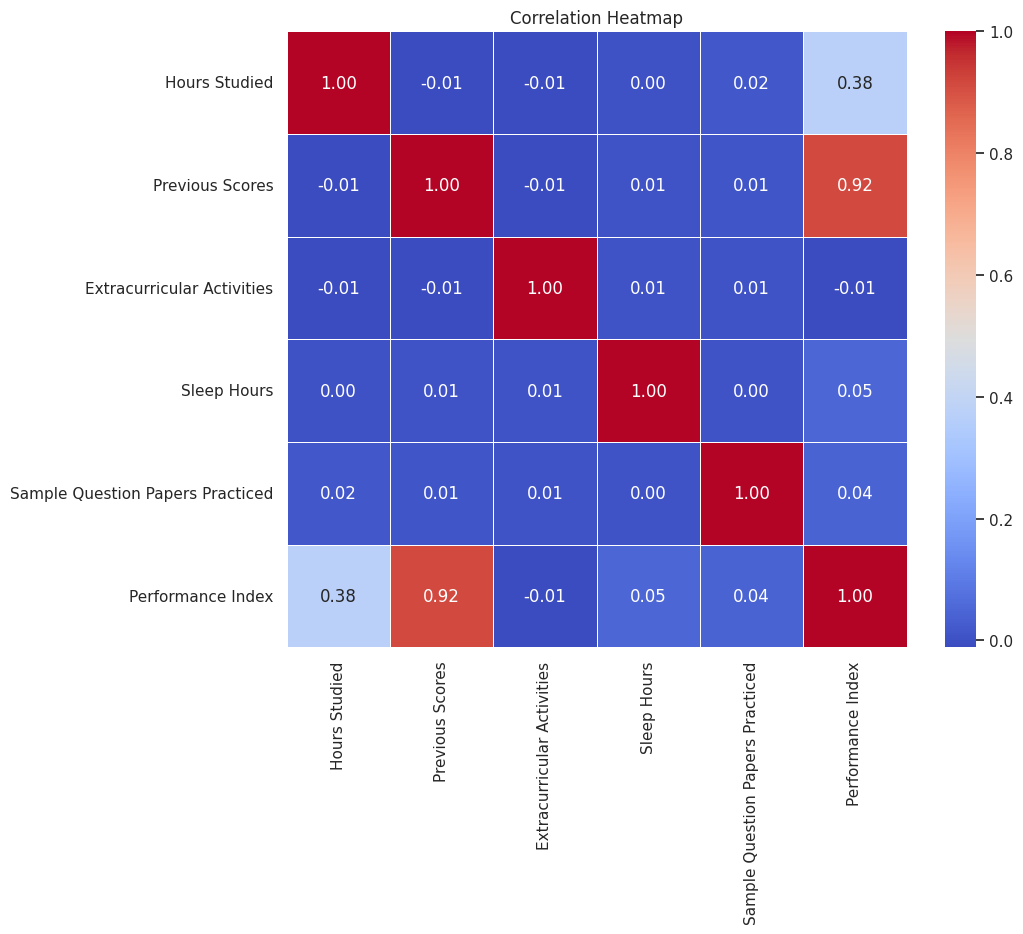

In [114]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlations with the target variable
print("Correlation of features with Performance Index:")
print(correlation_matrix['Performance Index'].sort_values(ascending=False))

# Visualize the correlations using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#provide p value and f score for each column

In [115]:
from sklearn.feature_selection import f_regression

# Prepare features (X) and target (y)
X_full = df.drop('Performance Index', axis=1)
y_full = df['Performance Index']

# Calculate F-scores and p-values
f_scores, p_values = f_regression(X_full, y_full)

# Create a summary DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_full.columns,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

print("Statistical Significance of Features (f_regression):")
display(feature_importance)

Statistical Significance of Features (f_regression):


,Feature,F-Score,p-value
1,Previous Scores,50863.230088,0.000000e+00
0,Hours Studied,1618.585346,0.000000e+00
3,Sleep Hours,25.090267,5.565559e-07
4,Sample Question Papers Practiced,18.658435,1.578832e-05
2,Extracurricular Activities,1.307474,2.528802e-01


#chi-square score

In [116]:
from sklearn.feature_selection import chi2, SelectKBest

# Chi-square requires non-negative categorical target.
# We'll bin 'Performance Index' into 10 categories to represent 'Performance Levels'
y_binned = pd.qcut(df['Performance Index'], q=10, labels=False)

# All features must be non-negative (which they are in this dataset)
X_chi = df.drop('Performance Index', axis=1)

# Calculate Chi-Square scores and p-values
chi_scores, p_values_chi = chi2(X_chi, y_binned)

# Create a summary DataFrame
chi_importance = pd.DataFrame({
    'Feature': X_chi.columns,
    'Chi-Square Score': chi_scores,
    'p-value': p_values_chi
}).sort_values(by='Chi-Square Score', ascending=False)

print('Chi-Square Significance of Features (against binned Performance Index):')
display(chi_importance)

Chi-Square Significance of Features (against binned Performance Index):


,Feature,Chi-Square Score,p-value
1,Previous Scores,35928.972721,0.000000
0,Hours Studied,2451.330579,0.000000
4,Sample Question Papers Practiced,39.265352,0.000010
3,Sleep Hours,13.010699,0.162123
2,Extracurricular Activities,1.544429,0.996804


#remove weak corelated column

In [117]:
# Based on correlation analysis, removing weak features (correlation < 0.1)
columns_to_drop = ['Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
X_filtered = X_full.drop(columns=columns_to_drop)

print('Remaining features after removing weak correlations:')
print(X_filtered.columns.tolist())
display(X_filtered.head())

Remaining features after removing weak correlations:
['Hours Studied', 'Previous Scores']


,Hours Studied,Previous Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75


#Split Dataset

In [118]:
from sklearn.model_selection import train_test_split

# Split the filtered features and target variable
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_full, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nFirst 5 rows of X_train:")
display(X_train.head())

Training set shape: (7898, 2)
Testing set shape: (1975, 2)

First 5 rows of X_train:


,Hours Studied,Previous Scores
8495,5,71
9012,2,57
4092,1,49
811,3,58
6789,3,80


#Apply StandardScaler

In [119]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('Scaled training data (first 5 rows):')
display(X_train_scaled.head())

Scaled training data (first 5 rows):


,Hours Studied,Previous Scores
0,0.003721,0.096536
1,-1.156282,-0.712663
2,-1.542949,-1.175062
3,-0.769614,-0.654863
4,-0.769614,0.616735


#Check Scaled Output

In [121]:
# Check statistics of the scaled training data
print('Summary statistics for scaled training data:')
display(X_train_scaled.describe().round(4))

# Also show the first 5 rows of scaled test data to ensure it was transformed correctly
print('\nScaled testing data (first 5 rows):')
display(X_test_scaled.head())

Summary statistics for scaled training data:


,Hours Studied,Previous Scores
count,7898.0000,7898.0000
mean,-0.0000,-0.0000
std,1.0001,1.0001
min,-1.5429,-1.6953
25%,-0.7696,-0.8861
50%,0.0037,-0.0191
75%,0.7771,0.9057
max,1.5504,1.7149



Scaled testing data (first 5 rows):


,Hours Studied,Previous Scores
0,-0.382947,-0.308064
1,0.777056,1.194734
2,0.390388,0.212135
3,-0.769614,-1.521862
4,1.550391,0.385535


#Verify Dataset Shape After Scaling

In [122]:
# Verify the shapes of the scaled datasets
print(f"Scaled training features shape: {X_train_scaled.shape}")
print(f"Scaled testing features shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Scaled training features shape: (7898, 2)
Scaled testing features shape: (1975, 2)
Training target shape: (7898,)
Testing target shape: (1975,)


#Apply PCA on Scaled Training Data

In [123]:
from sklearn.decomposition import PCA

# Initialize PCA. Since we have 2 features, we can look at both components.
pca = PCA()

# Fit PCA on the scaled training data and transform it
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform the test data using the same PCA mapping
X_test_pca = pca.transform(X_test_scaled)

# Calculate Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print('Explained Variance Ratio for each Principal Component:')
for i, ratio in enumerate(explained_variance):
    print(f'PC{i+1}: {ratio:.4f}')

print(f'\nTotal variance explained by first component: {explained_variance[0]*100:.2f}%')

# Create a DataFrame for PCA results
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
print('\nFirst 5 rows of PCA-transformed training data:')
display(X_train_pca_df.head())

Explained Variance Ratio for each Principal Component:
PC1: 0.5044
PC2: 0.4956

Total variance explained by first component: 50.44%

First 5 rows of PCA-transformed training data:


,PC1,PC2
0,0.065630,0.070892
1,0.313686,-1.321544
2,0.260135,-1.921924
3,0.081141,-1.007258
4,0.980297,-0.108102


# Visualize the explained variance ratio

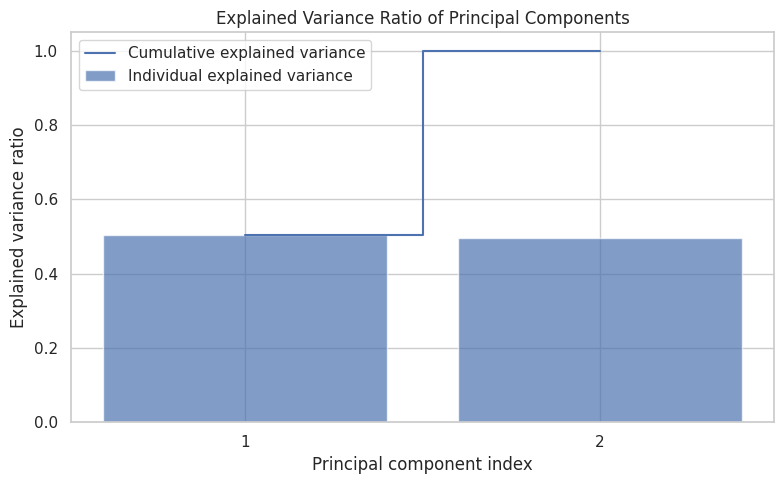

Principal Component 1: 0.5044 (50.44%)
Principal Component 2: 0.4956 (49.56%)
Total Cumulative Variance: 100.00%


In [124]:
# Visualize the explained variance ratio
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', label='Individual explained variance')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Explained Variance Ratio of Principal Components')
plt.legend(loc='best')
plt.xticks(range(1, len(explained_variance) + 1))
plt.tight_layout()
plt.show()

# Print the numerical values
for i, ratio in enumerate(explained_variance):
    print(f'Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}%)')
print(f'Total Cumulative Variance: {np.sum(explained_variance)*100:.2f}%')

In [125]:
# Based on the explained variance, we can decide how many components to keep.
# For demonstration, let's select the components that explain at least 95% of variance.
# In this specific case, both PC1 and PC2 are needed for ~100% variance.

n_components_to_keep = 1  # Change this to 2 to keep all information

# Selecting the components from our transformed training and testing sets
X_train_final = X_train_pca[:, :n_components_to_keep]
X_test_final = X_test_pca[:, :n_components_to_keep]

# Convert to DataFrame for clarity
component_names = [f'PC{i+1}' for i in range(n_components_to_keep)]
X_train_final_df = pd.DataFrame(X_train_final, columns=component_names)

print(f'Selected {n_components_to_keep} Principal Component(s).')
print('\nFinal processed training features (first 5 rows):')
display(X_train_final_df.head())

Selected 1 Principal Component(s).

Final processed training features (first 5 rows):


,PC1
0,0.065630
1,0.313686
2,0.260135
3,0.081141
4,0.980297


In [126]:
# Verify the shapes of the final PCA datasets
print(f"Final training features shape (PCA): {X_train_final.shape}")
print(f"Final testing features shape (PCA): {X_test_final.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Final training features shape (PCA): (7898, 1)
Final testing features shape (PCA): (1975, 1)
Training target shape: (7898,)
Testing target shape: (1975,)


## Create 'Study Efficiency' feature

In [128]:
# Create 'Study Efficiency' feature
# We use 'Previous Scores' / 'Hours Studied' to represent efficiency
df['Study Efficiency'] = df['Previous Scores'] / df['Hours Studied']

# Handle potential division by zero if Hours Studied is 0 (though unlikely in this dataset)
df['Study Efficiency'] = df['Study Efficiency'].replace([np.inf, -np.inf], 0)

print('New feature "Study Efficiency" created:')
display(df[['Hours Studied', 'Previous Scores', 'Study Efficiency', 'Performance Index']].head())

New feature "Study Efficiency" created:


,Hours Studied,Previous Scores,Study Efficiency,Performance Index
0,7,99,14.142857,91.0
1,4,82,20.500000,65.0
2,8,51,6.375000,45.0
3,5,52,10.400000,36.0
4,7,75,10.714286,66.0


# Create 'Practice Efficiency' feature

In [129]:
# Create 'Practice Efficiency' feature
df['Practice Efficiency'] = df['Sample Question Papers Practiced'] / df['Hours Studied']

# Handle division by zero and infinity
df['Practice Efficiency'] = df['Practice Efficiency'].replace([np.inf, -np.inf], 0).fillna(0)

print('New feature "Practice Efficiency" created:')
display(df[['Hours Studied', 'Sample Question Papers Practiced', 'Practice Efficiency', 'Performance Index']].head())

New feature "Practice Efficiency" created:


,Hours Studied,Sample Question Papers Practiced,Practice Efficiency,Performance Index
0,7,1,0.142857,91.0
1,4,2,0.500000,65.0
2,8,2,0.250000,45.0
3,5,2,0.400000,36.0
4,7,5,0.714286,66.0


# Create 'Study-Sleep Balance' feature

In [130]:
# Create 'Study-Sleep Balance' feature
df['Study-Sleep Balance'] = df['Hours Studied'] / df['Sleep Hours']

# Handle division by zero or infinity (though Sleep Hours is unlikely to be 0)
df['Study-Sleep Balance'] = df['Study-Sleep Balance'].replace([np.inf, -np.inf], 0).fillna(0)

print('New feature "Study-Sleep Balance" created:')
display(df[['Hours Studied', 'Sleep Hours', 'Study-Sleep Balance', 'Performance Index']].head())

New feature "Study-Sleep Balance" created:


,Hours Studied,Sleep Hours,Study-Sleep Balance,Performance Index
0,7,9,0.777778,91.0
1,4,4,1.000000,65.0
2,8,7,1.142857,45.0
3,5,5,1.000000,36.0
4,7,8,0.875000,66.0


# Create 'Academic Engagement' feature

In [131]:
# Create 'Academic Engagement' feature
df['Academic Engagement'] = df['Hours Studied'] + df['Sample Question Papers Practiced']

print('New feature "Academic Engagement" created:')
display(df[['Hours Studied', 'Sample Question Papers Practiced', 'Academic Engagement', 'Performance Index']].head())

New feature "Academic Engagement" created:


,Hours Studied,Sample Question Papers Practiced,Academic Engagement,Performance Index
0,7,1,8,91.0
1,4,2,6,65.0
2,8,2,10,45.0
3,5,2,7,36.0
4,7,5,12,66.0


# Identify numerical columns for transformation

In [132]:
# Identify numerical columns for transformation
num_cols_to_transform = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Study Efficiency', 'Practice Efficiency', 'Study-Sleep Balance', 'Academic Engagement']

# Apply log transformation (using log1p to handle 0s)
for col in num_cols_to_transform:
    df[f'log_{col}'] = np.log1p(df[col])

print('Log transformation applied to numerical features. First 5 rows of new log-features:')
log_cols = [f'log_{col}' for col in num_cols_to_transform]
display(df[log_cols].head())

Log transformation applied to numerical features. First 5 rows of new log-features:


,log_Hours Studied,log_Previous Scores,log_Sleep Hours,log_Sample Question Papers Practiced,log_Study Efficiency,log_Practice Efficiency,log_Study-Sleep Balance,log_Academic Engagement
0,2.079442,4.605170,2.302585,0.693147,2.717529,0.133531,0.575364,2.197225
1,1.609438,4.418841,1.609438,1.098612,3.068053,0.405465,0.693147,1.945910
2,2.197225,3.951244,2.079442,1.098612,1.998096,0.223144,0.762140,2.397895
3,1.791759,3.970292,1.791759,1.098612,2.433613,0.336472,0.693147,2.079442
4,2.079442,4.330733,2.197225,1.791759,2.460809,0.538997,0.628609,2.564949


# Check the list of all current columns

In [133]:
# Check the list of all current columns
print("Current columns in the dataset:")
print(df.columns.tolist())

# Display the first 5 rows for a comprehensive view of new features
print("\nPreview of the updated dataset with new features:")
display(df.head())

Current columns in the dataset:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index', 'Study Efficiency', 'Practice Efficiency', 'Study-Sleep Balance', 'Academic Engagement', 'log_Hours Studied', 'log_Previous Scores', 'log_Sleep Hours', 'log_Sample Question Papers Practiced', 'log_Study Efficiency', 'log_Practice Efficiency', 'log_Study-Sleep Balance', 'log_Academic Engagement']

Preview of the updated dataset with new features:


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Study Efficiency,Practice Efficiency,Study-Sleep Balance,Academic Engagement,log_Hours Studied,log_Previous Scores,log_Sleep Hours,log_Sample Question Papers Practiced,log_Study Efficiency,log_Practice Efficiency,log_Study-Sleep Balance,log_Academic Engagement
0,7,99,1,9,1,91.0,14.142857,0.142857,0.777778,8,2.079442,4.605170,2.302585,0.693147,2.717529,0.133531,0.575364,2.197225
1,4,82,0,4,2,65.0,20.500000,0.500000,1.000000,6,1.609438,4.418841,1.609438,1.098612,3.068053,0.405465,0.693147,1.945910
2,8,51,1,7,2,45.0,6.375000,0.250000,1.142857,10,2.197225,3.951244,2.079442,1.098612,1.998096,0.223144,0.762140,2.397895
3,5,52,1,5,2,36.0,10.400000,0.400000,1.000000,7,1.791759,3.970292,1.791759,1.098612,2.433613,0.336472,0.693147,2.079442
4,7,75,0,8,5,66.0,10.714286,0.714286,0.875000,12,2.079442,4.330733,2.197225,1.791759,2.460809,0.538997,0.628609,2.564949


# Calculate correlation matrix for all current features

Correlation of all features with Performance Index:


,Performance Index
Performance Index,1.000000
Previous Scores,0.915135
log_Previous Scores,0.909012
Hours Studied,0.375332
log_Hours Studied,0.368023
log_Study-Sleep Balance,0.314190
Study-Sleep Balance,0.299234
Academic Engagement,0.281587
log_Academic Engagement,0.272078
Sleep Hours,0.050352


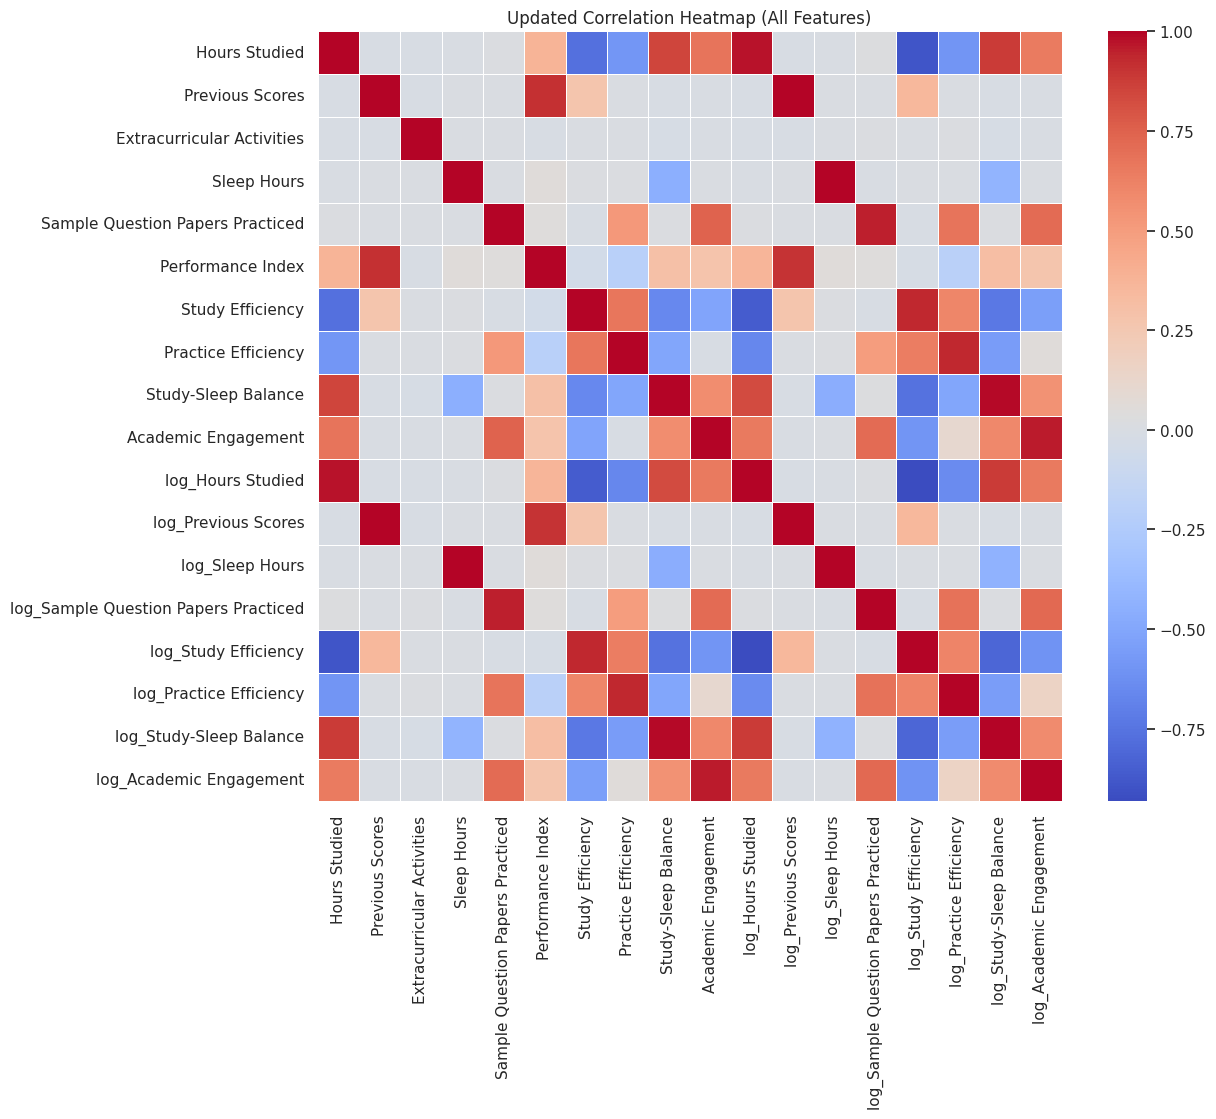

In [134]:
# Calculate correlation matrix for all current features
new_correlation_matrix = df.corr()

# Sort correlations with the target variable
performance_corr = new_correlation_matrix['Performance Index'].sort_values(ascending=False)

print("Correlation of all features with Performance Index:")
display(performance_corr)

# Visualize the top correlations using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(new_correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Updated Correlation Heatmap (All Features)')
plt.show()

In [135]:
# Define the final selected features based on high correlation (> 0.3)
# We'll include both original and log-transformed for strong predictors
final_features = ['Previous Scores', 'Hours Studied', 'log_Previous Scores', 'log_Hours Studied']

X_final_model = df[final_features]
y_final_model = df['Performance Index']

print('Updated Feature Set for final modeling:')
print(X_final_model.columns.tolist())
display(X_final_model.head())

Updated Feature Set for final modeling:
['Previous Scores', 'Hours Studied', 'log_Previous Scores', 'log_Hours Studied']


,Previous Scores,Hours Studied,log_Previous Scores,log_Hours Studied
0,99,7,4.605170,2.079442
1,82,4,4.418841,1.609438
2,51,8,3.951244,2.197225
3,52,5,3.970292,1.791759
4,75,7,4.330733,2.079442


Correlation of final selected features with Performance Index:


,Performance Index
Performance Index,1.000000
Previous Scores,0.915135
log_Previous Scores,0.909012
Hours Studied,0.375332
log_Hours Studied,0.368023


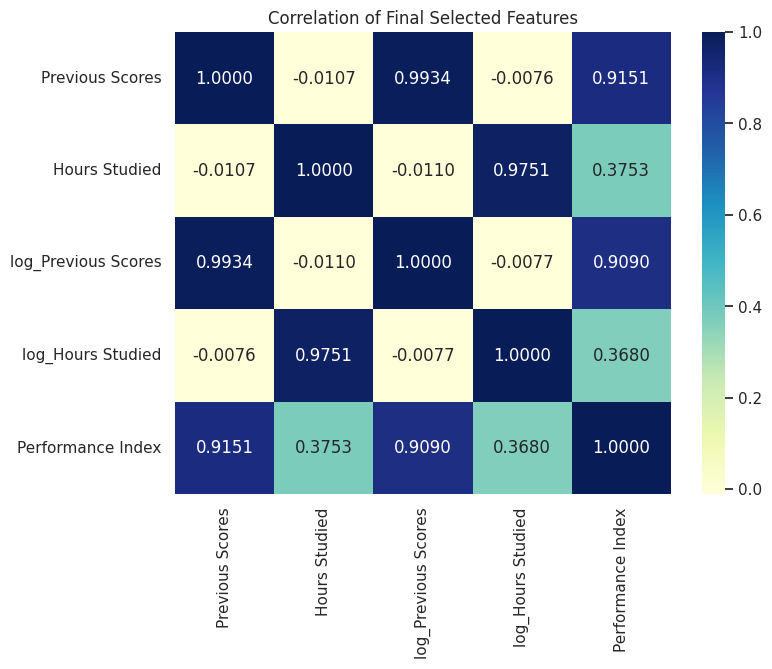

In [136]:
# Analyze correlation for the final feature set
final_corr = X_final_model.join(y_final_model).corr()

print("Correlation of final selected features with Performance Index:")
display(final_corr[['Performance Index']].sort_values(by='Performance Index', ascending=False))

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(final_corr, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Correlation of Final Selected Features')
plt.show()

#VIF calculation

In [137]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare features for VIF calculation (VIF requires a constant/intercept)
X_vif = add_constant(X_final_model)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print('Variance Inflation Factor (VIF) for Final Features:')
display(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for Final Features:


,Feature,VIF
0,const,11757.973006
3,log_Previous Scores,75.635497
1,Previous Scores,75.632803
2,Hours Studied,20.306624
4,log_Hours Studied,20.305275


# Remove log-transformed features to reduce multicollinearity

In [138]:
# Remove log-transformed features to reduce multicollinearity
final_features_v2 = ['Previous Scores', 'Hours Studied']
X_final_model = df[final_features_v2]

print('Final feature set (logs removed):')
print(X_final_model.columns.tolist())

# Re-verify VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif_final = add_constant(X_final_model)
vif_final = pd.DataFrame()
vif_final['Feature'] = X_vif_final.columns
vif_final['VIF'] = [variance_inflation_factor(X_vif_final.values, i) for i in range(len(X_vif_final.columns))]

print('\nUpdated VIF scores:')
display(vif_final)

Final feature set (logs removed):
['Previous Scores', 'Hours Studied']

Updated VIF scores:


,Feature,VIF
0,const,20.951113
1,Previous Scores,1.000114
2,Hours Studied,1.000114


In [139]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare the final feature set for VIF calculation
X_vif_final = add_constant(df[['Previous Scores', 'Hours Studied']])

# Calculate VIF
vif_final_check = pd.DataFrame()
vif_final_check['Feature'] = X_vif_final.columns
vif_final_check['VIF'] = [variance_inflation_factor(X_vif_final.values, i) for i in range(len(X_vif_final.columns))]

print('Final VIF Scores (Confirming low multicollinearity):')
display(vif_final_check)

Final VIF Scores (Confirming low multicollinearity):


,Feature,VIF
0,const,20.951113
1,Previous Scores,1.000114
2,Hours Studied,1.000114


# RFE

In [140]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Initialize the model for RFE
lr = LinearRegression()

# Use all original numerical features for RFE to see what it picks
X_rfe = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']]
y_rfe = df['Performance Index']

# Initialize RFE and select top 2 features
rfe = RFE(estimator=lr, n_features_to_select=2)
rfe.fit(X_rfe, y_rfe)

# Create a summary of selected features
rfe_results = pd.DataFrame({
    'Feature': X_rfe.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

print('Recursive Feature Elimination (RFE) Results:')
display(rfe_results)

selected_rfe_features = X_rfe.columns[rfe.support_].tolist()
print(f'\nTop features selected by RFE: {selected_rfe_features}')

Recursive Feature Elimination (RFE) Results:


,Feature,Selected,Ranking
0,Hours Studied,True,1
1,Previous Scores,True,1
3,Sleep Hours,False,2
4,Sample Question Papers Practiced,False,3
2,Extracurricular Activities,False,4



Top features selected by RFE: ['Hours Studied', 'Previous Scores']


In [141]:
# Define the final chosen features
final_selected_features = ['Hours Studied', 'Previous Scores']

# Create final Features (X) and Target (y)
X_final = df[final_selected_features]
y_final = df['Performance Index']

print('Final Dataset for Modeling Prepared:')
print(f'Features: {X_final.columns.tolist()}')
print(f'Shape: {X_final.shape}')
display(X_final.head())

Final Dataset for Modeling Prepared:
Features: ['Hours Studied', 'Previous Scores']
Shape: (9873, 2)


,Hours Studied,Previous Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75


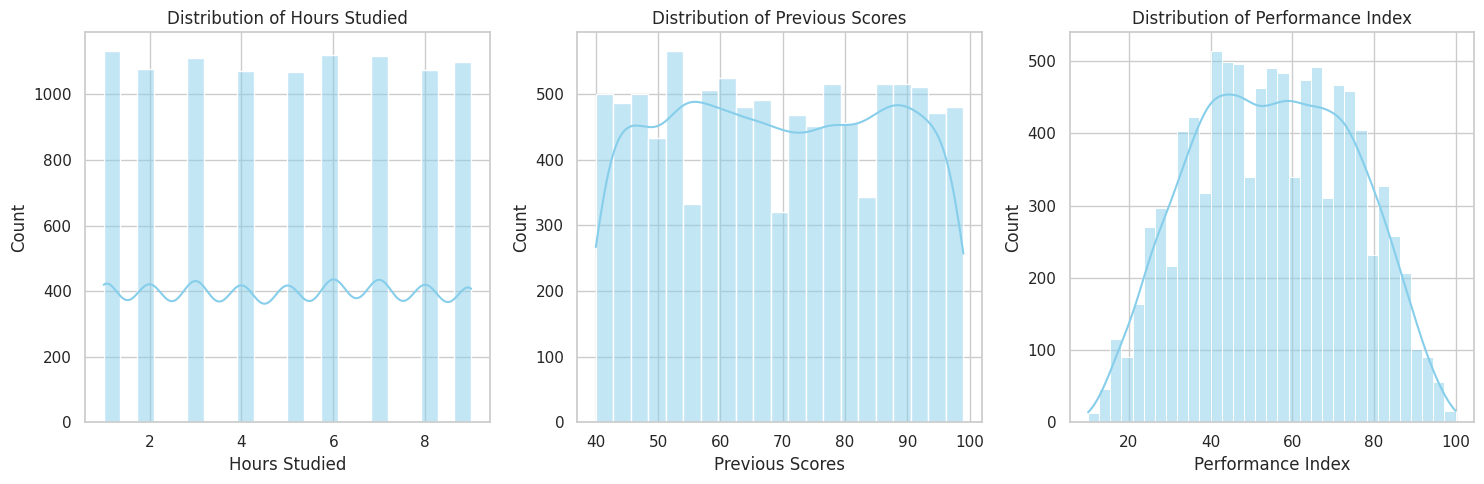

/tmp/ipykernel_12261/228373730.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Extracurricular Activities', data=df, palette='viridis')


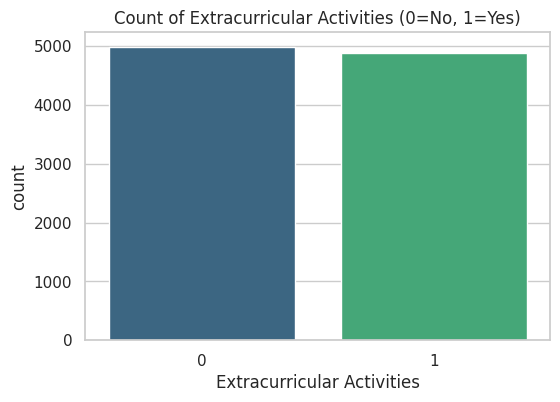

Value counts for Extracurricular Activities:
Extracurricular Activities
0    4989
1    4884
Name: count, dtype: int64


In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style='whitegrid')

# 1. Histograms for numeric features
num_features = ['Hours Studied', 'Previous Scores', 'Performance Index']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# 2. Bar plot for categorical feature (Extracurricular Activities)
plt.figure(figsize=(6, 4))
sns.countplot(x='Extracurricular Activities', data=df, palette='viridis')
plt.title('Count of Extracurricular Activities (0=No, 1=Yes)')
plt.show()

# Display value counts for clarity
print('Value counts for Extracurricular Activities:')
print(df['Extracurricular Activities'].value_counts())

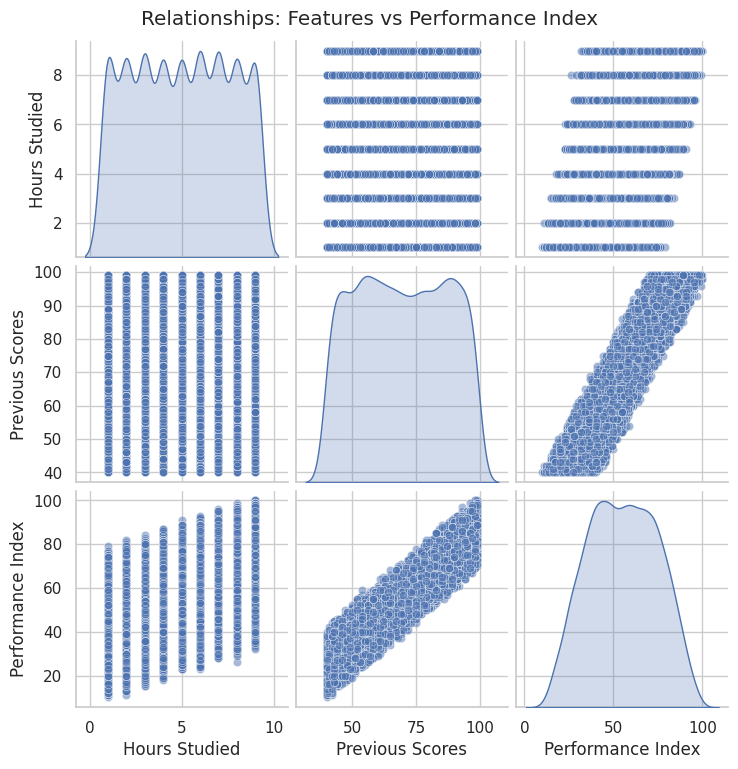

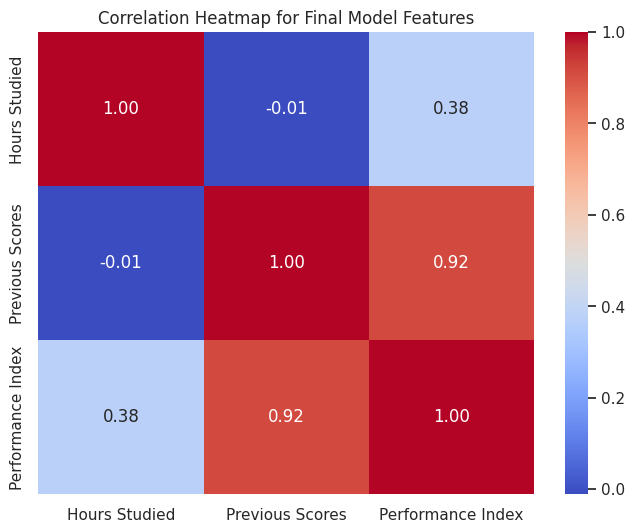

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pairplot to see relationships between selected features and target
sns.pairplot(df[['Hours Studied', 'Previous Scores', 'Performance Index']], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Relationships: Features vs Performance Index', y=1.02)
plt.show()

# 2. Focused Heatmap for the modeling features
plt.figure(figsize=(8, 6))
model_cols = ['Hours Studied', 'Previous Scores', 'Performance Index']
sns.heatmap(df[model_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Final Model Features')
plt.show()

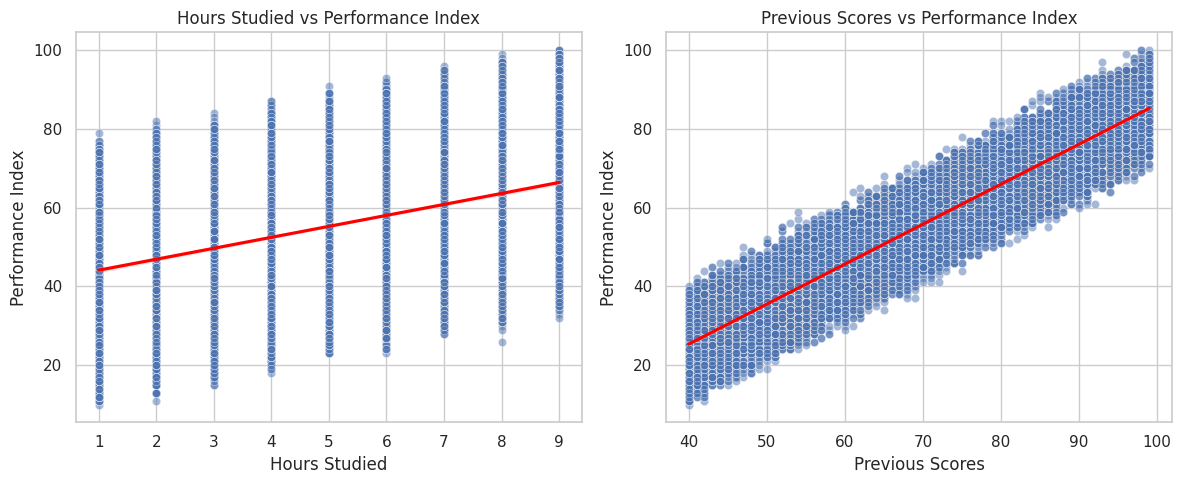

In [144]:
# Create individual scatter plots for key features vs Performance Index
plt.figure(figsize=(12, 5))

# Scatter plot for Hours Studied
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Hours Studied', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Hours Studied', y='Performance Index', scatter=False, color='red')
plt.title('Hours Studied vs Performance Index')

# Scatter plot for Previous Scores
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Previous Scores', y='Performance Index', alpha=0.5)
sns.regplot(data=df, x='Previous Scores', y='Performance Index', scatter=False, color='red')
plt.title('Previous Scores vs Performance Index')

plt.tight_layout()
plt.show()

/tmp/ipykernel_12261/1797147792.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Extracurricular Activities', palette='pastel')
/tmp/ipykernel_12261/1797147792.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Extracurricular Activities', y='Performance Index', palette='pastel')


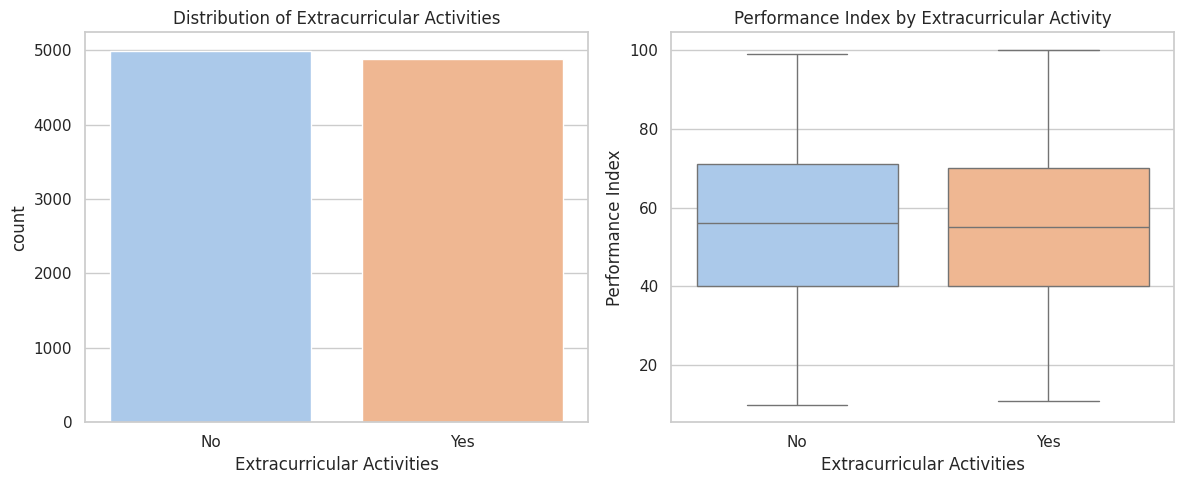

In [145]:
# Set visualization style
sns.set(style='whitegrid')

# 1. Count plot for 'Extracurricular Activities'
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Extracurricular Activities', palette='pastel')
plt.title('Distribution of Extracurricular Activities')
plt.xticks([0, 1], ['No', 'Yes'])

# 2. Box plot for Performance Index vs Extracurricular Activities
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Extracurricular Activities', y='Performance Index', palette='pastel')
plt.title('Performance Index by Extracurricular Activity')
plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()
plt.show()

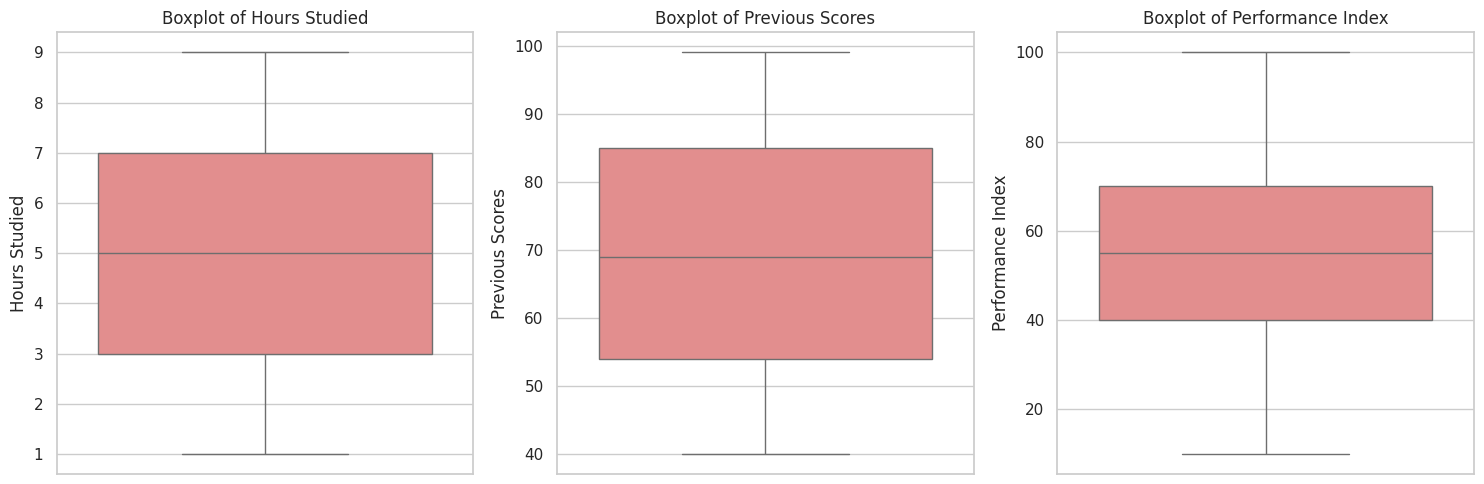

Outlier Analysis (IQR Method):
Hours Studied: 0 outliers found (Lower: -3.00, Upper: 13.00)
Previous Scores: 0 outliers found (Lower: 7.50, Upper: 131.50)
Performance Index: 0 outliers found (Lower: -5.00, Upper: 115.00)


In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplots for numeric features to visually identify outliers
num_cols = ['Hours Studied', 'Previous Scores', 'Performance Index']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# 2. Quantify outliers using the IQR method
print("Outlier Analysis (IQR Method):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found (Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f})")

#  Visualization of Target Variable

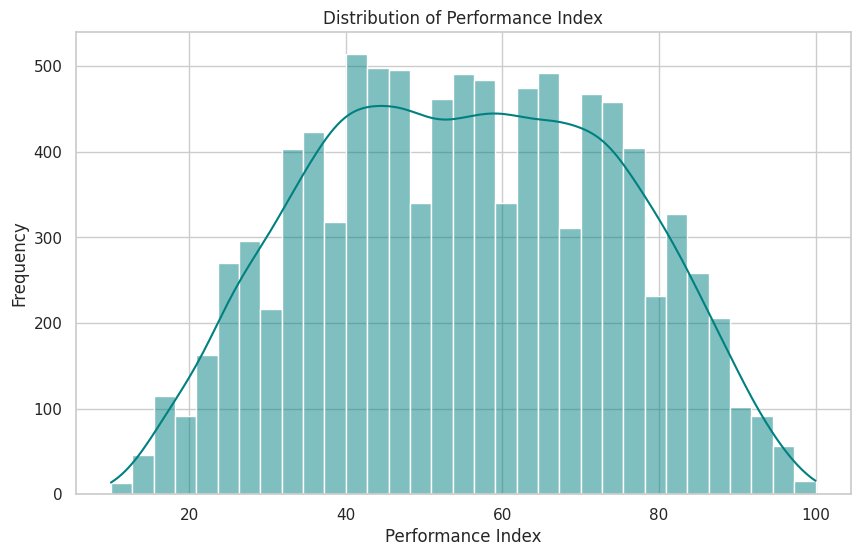

Skewness of Performance Index: -0.0004
Kurtosis of Performance Index: -0.8603
The distribution is approximately symmetric.


In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 1. Visualization of Target Variable
plt.figure(figsize=(10, 6))
sns.histplot(df['Performance Index'], kde=True, color='teal')
plt.title('Distribution of Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')
plt.show()

# 2. Statistical checks for normality
target_skew = skew(df['Performance Index'])
target_kurt = kurtosis(df['Performance Index'])

print(f"Skewness of Performance Index: {target_skew:.4f}")
print(f"Kurtosis of Performance Index: {target_kurt:.4f}")

if abs(target_skew) < 0.5:
    print("The distribution is approximately symmetric.")
else:
    print("The distribution is skewed.")

In [148]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
# We'll use the final selected features identified earlier
X = df[['Hours Studied', 'Previous Scores']]
y = df['Performance Index']

# Perform the split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
display(X_train.head())

Training set shape: (7898, 2)
Testing set shape: (1975, 2)


,Hours Studied,Previous Scores
8495,5,71
9012,2,57
4092,1,49
811,3,58
6789,3,80


#LinearRegression

In [149]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the model
model = LinearRegression()

# 2. Train the model
model.fit(X_train, y_train)

# 3. Make predictions
y_pred = model.predict(X_test)

# 4. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Display coefficients
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print("\nModel Coefficients:")
display(coeffs)
print(f"Intercept: {model.intercept_:.4f}")

Model Performance Metrics:
Mean Squared Error (MSE): 5.5738
R-squared (R2): 0.9850

Model Coefficients:


,Feature,Coefficient
0,Hours Studied,2.855064
1,Previous Scores,1.018757


Intercept: -29.7821


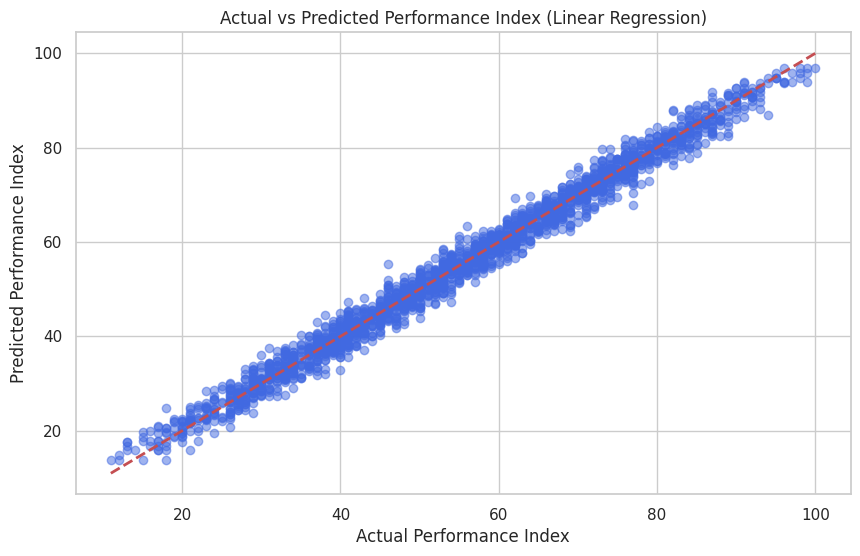

In [150]:
# Visualize Actual vs Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted Performance Index (Linear Regression)')
plt.grid(True)
plt.show()

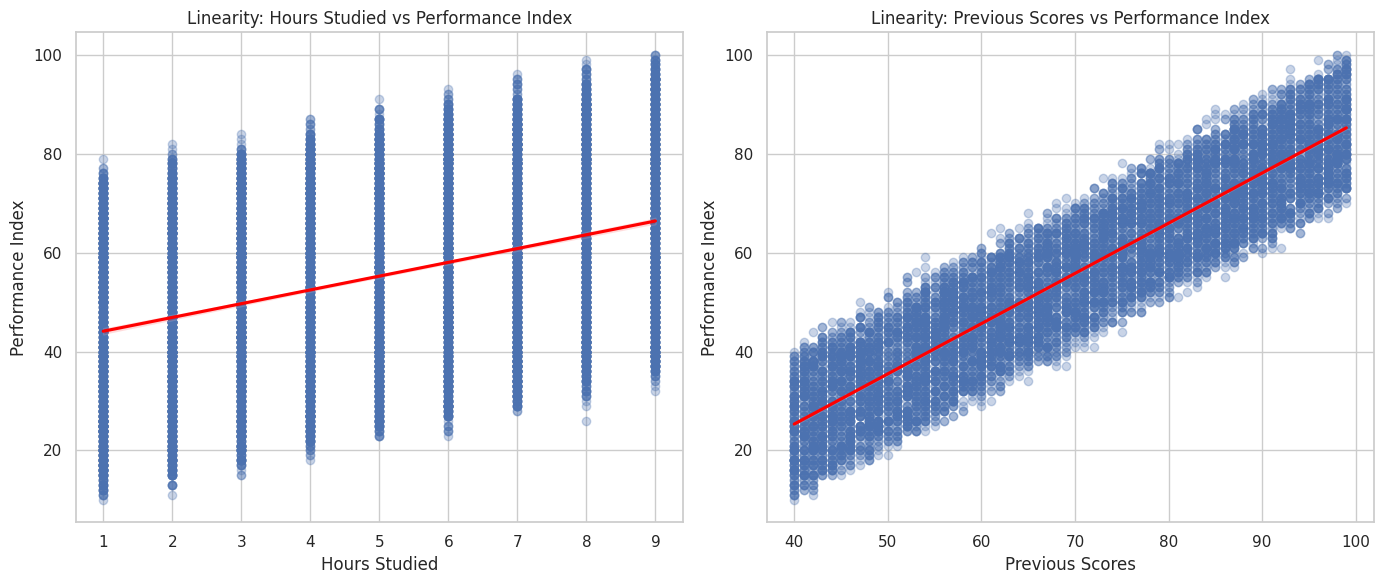

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Linearity check: Scatter plots of each feature vs the target variable with a regression line
features_to_check = ['Hours Studied', 'Previous Scores']

plt.figure(figsize=(14, 6))

for i, col in enumerate(features_to_check):
    plt.subplot(1, 2, i+1)
    sns.regplot(x=df[col], y=df['Performance Index'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Linearity: {col} vs Performance Index')
    plt.grid(True)

plt.tight_layout()
plt.show()

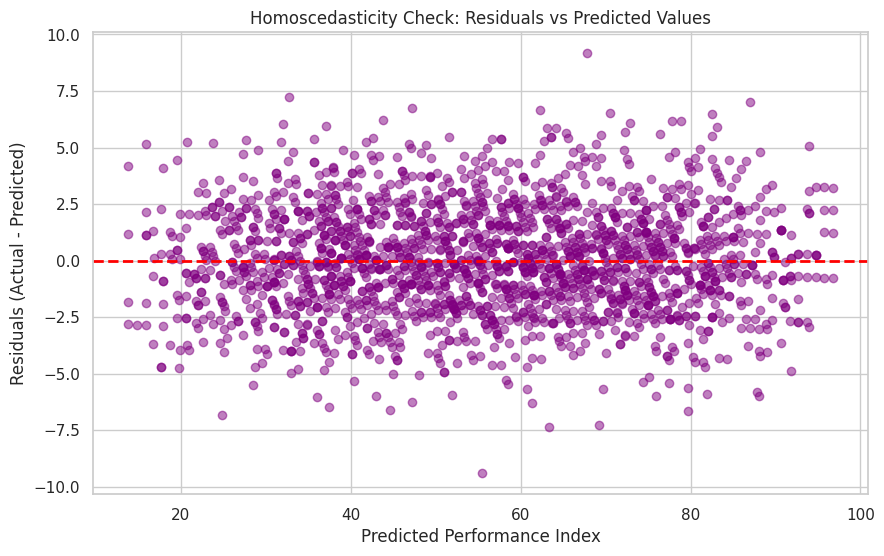

If the points are randomly dispersed around the horizontal line, the assumption of homoscedasticity is met.


In [152]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Performance Index')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Homoscedasticity Check: Residuals vs Predicted Values')
plt.grid(True)
plt.show()

# Optional: Check for specific patterns
print("If the points are randomly dispersed around the horizontal line, the assumption of homoscedasticity is met.")

In [153]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare features for VIF calculation
X_vif = add_constant(X_train)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print('Variance Inflation Factor (VIF) for Training Features:')
display(vif_data)

# Interpretation
print("\nInterpretation: A VIF near 1 suggests no correlation. A VIF > 5 or 10 indicates high multicollinearity.")

Variance Inflation Factor (VIF) for Training Features:


,Feature,VIF
0,const,20.919085
1,Hours Studied,1.000077
2,Previous Scores,1.000077



Interpretation: A VIF near 1 suggests no correlation. A VIF > 5 or 10 indicates high multicollinearity.


# Endogeneity Check

In [154]:
# Endogeneity Check: Correlation between Residuals and Features
# Using the test set for consistency with previous evaluations
endogeneity_check = X_test.copy()
endogeneity_check['Residuals'] = residuals

correlation_with_residuals = endogeneity_check.corr()['Residuals'].drop('Residuals')

print("Correlation between Features and Residuals:")
display(correlation_with_residuals)

print("\nInterpretation: Correlations close to 0 suggest that the predictors are exogenous (no endogeneity).")

Correlation between Features and Residuals:


,Residuals
Hours Studied,0.012708
Previous Scores,0.014151



Interpretation: Correlations close to 0 suggest that the predictors are exogenous (no endogeneity).


# Create the Q-Q plot

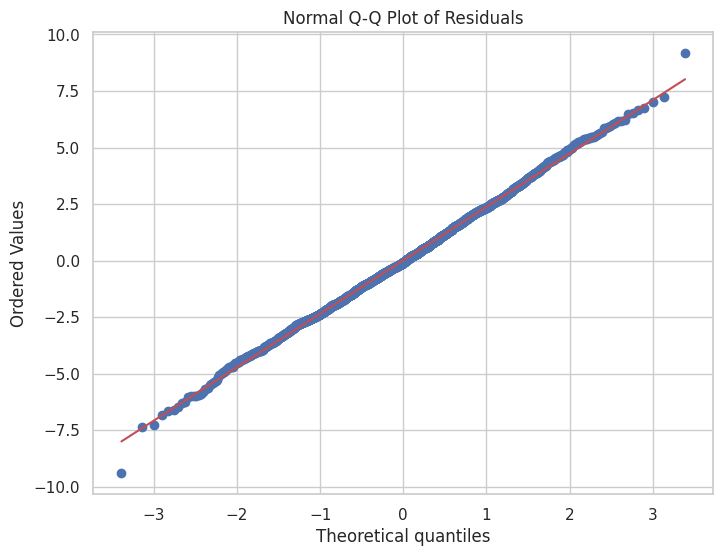

Interpretation: If the points follow the straight line, the residuals are normally distributed.


In [155]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Create the Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

print("Interpretation: If the points follow the straight line, the residuals are normally distributed.")

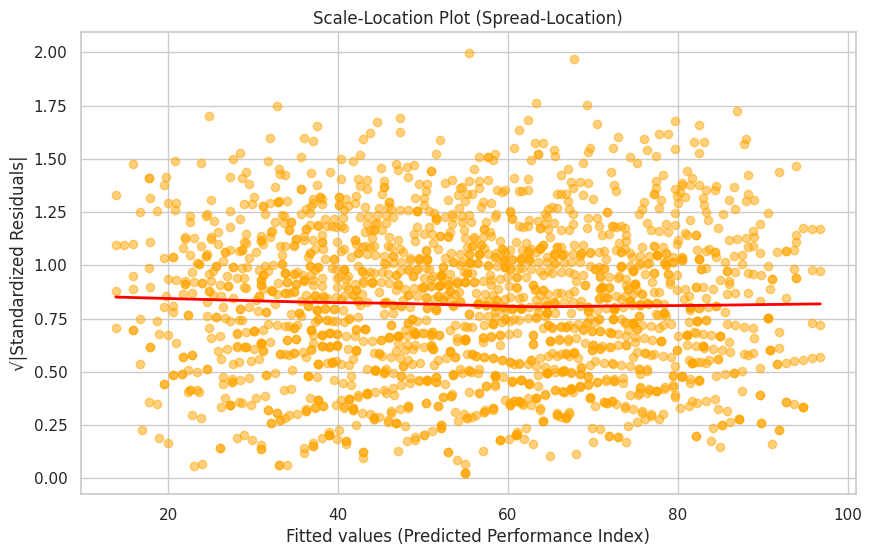

Interpretation: A horizontal line with equally spread points indicates homoscedasticity.


In [156]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate standardized residuals
standardized_residuals = residuals / np.std(residuals)

# Calculate square root of absolute standardized residuals
sqrt_abs_standardized_residuals = np.sqrt(np.abs(standardized_residuals))

# Plot Scale-Location
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, sqrt_abs_standardized_residuals, alpha=0.5, color='orange')

# Add a smooth line (trendline) to help identify patterns
sns.regplot(x=y_pred, y=sqrt_abs_standardized_residuals, scatter=False, ci=None, lowess=True, line_kws={'color': 'red', 'lw': 2})

plt.xlabel('Fitted values (Predicted Performance Index)')
plt.ylabel('√|Standardized Residuals|')
plt.title('Scale-Location Plot (Spread-Location)')
plt.grid(True)
plt.show()

print("Interpretation: A horizontal line with equally spread points indicates homoscedasticity.")

In [157]:
import numpy as np

# Identify numerical columns for transformation
num_cols_to_transform = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# Apply log transformation (using log1p to handle 0s)
for col in num_cols_to_transform:
    df[f'log_{col}'] = np.log1p(df[col])

print('Log transformation applied to numerical features. First 5 rows of new log-features:')
log_cols = [f'log_{col}' for col in num_cols_to_transform]
display(df[log_cols].head())

Log transformation applied to numerical features. First 5 rows of new log-features:


,log_Hours Studied,log_Previous Scores,log_Sleep Hours,log_Sample Question Papers Practiced
0,2.079442,4.605170,2.302585,0.693147
1,1.609438,4.418841,1.609438,1.098612
2,2.197225,3.951244,2.079442,1.098612
3,1.791759,3.970292,1.791759,1.098612
4,2.079442,4.330733,2.197225,1.791759


In [158]:
# Quickly check the correlation of log-transformed features with the target
log_corr = df[log_cols + ['Performance Index']].corr()
print('Correlation of log-transformed features with Performance Index:')
display(log_corr[['Performance Index']].sort_values(by='Performance Index', ascending=False))

Correlation of log-transformed features with Performance Index:


,Performance Index
Performance Index,1.000000
log_Previous Scores,0.909012
log_Hours Studied,0.368023
log_Sleep Hours,0.049712
log_Sample Question Papers Practiced,0.045134
